In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.config import Configuration
CONFIG = Configuration()

In [2]:
from maikol_utils.file_utils import list_dir_files

train_files, _ = list_dir_files(CONFIG.faces_test_path)
test_files, _ = list_dir_files(CONFIG.faces_train_path)

set(train_files).intersection(set(test_files))

set()

In [6]:
cascade_paths = [
    Configuration(computed_haar_cascades_name='haar_cascade_stage_28_fpr_0.0000000000_999.xml'),
    Configuration(computed_haar_cascades_name='haar_cascade_stage_23_fpr_0.0000000000_99.xml'),
    Configuration(computed_haar_cascades_name='haar_cascade_stage_21_fpr_0.0000000000_999_pfp.xml'),
    Configuration(computed_haar_cascades_name='haar_cascade_stage_18_fpr_0.0000000000_99_pfp.xml')
]


In [7]:
from src.data import get_image_crops_from_list

from maikol_utils.file_utils import list_dir_files

all_crops, cn = list_dir_files(CONFIG.no_faces_crops_path)
# all_crops, cn = list_dir_files(os.path.join('..', 'data', 'ViolaJones', 'pacheco', 'dataset', 'background_crops'))
# all_crops, cn = list_dir_files('../data/ViolaJones/pacheco/dataset/background_crops')
# test_faces, tn = list_dir_files(CONFIG.faces_test_path)
# test_faces, tn = list_dir_files(CONFIG.faces_vpc_path)
test_faces, tn = list_dir_files(CONFIG.faces_cv_passed_path)
print(f"Total crops in no_facescrops directory: {cn}")
print(f"Total crops in faces_test directory: {tn}")




Total crops in no_facescrops directory: 2491154
Total crops in faces_test directory: 51228


# Evaluate All Models


In [8]:
import os
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import cv2
import numpy as np
from PIL import Image
from src.model import load_cascade, CascadeClassifier

max_workers = min(32, (os.cpu_count() or 1) * 2)

results = []  # list of dicts per model

for cfg in cascade_paths:
    model_name = cfg.computed_haar_cascades_name.replace('.xml', '')
    print(f"\n=== Evaluating {model_name} ===")
    
    cascade = load_cascade(cfg.computed_haar_cascades_path)
    cfg.crop_size = max(cascade.height, cascade.width)
    classifier = CascadeClassifier(cfg, cascade)
    
    # -- FPR (no-faces) --
    def _predict_nf(img_path):
        fps, candidates = classifier.predict_no_merge(img_path=img_path, return_candidate_count=True)
        return img_path, fps, candidates
    
    all_fps, total_candidates_nf = [], 0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        results_nf = ex.map(_predict_nf, all_crops)
        for img_path, fps, candidates in tqdm(results_nf, total=len(all_crops), desc=f"FPR {model_name}"):
            all_fps.extend({"path": img_path, "face": face} for face in fps)
            total_candidates_nf += candidates
    
    fpr = (len(all_fps) / total_candidates_nf) if total_candidates_nf else 0.0
    
    # -- TPR (faces) --
    def _predict_f(img_path):
        faces, candidates = classifier.predict(img_path=img_path, return_candidate_count=True)
        return img_path, faces, candidates
    
    all_faces, total_candidates_f, right_preds = [], 0, 0
    missed_paths = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        results_f = ex.map(_predict_f, test_faces)
        for img_path, faces, candidates in tqdm(results_f, total=len(test_faces), desc=f"TPR {model_name}"):
            all_faces.extend(faces)
            if len(faces) > 0:
                right_preds += 1
            else:
                missed_paths.append(img_path)
            total_candidates_f += candidates
    
    tpr = (right_preds / len(test_faces)) if test_faces else 0.0
    
    print(f"FPR: {fpr:.10%} | Hit Rate: {tpr:.4%} | Missed: {len(missed_paths)}")
    
    results.append({
        "name": model_name,
        "classifier": classifier,
        "fpr": fpr,
        "tpr": tpr,
        "missed_paths": missed_paths,
    })



=== Evaluating haar_cascade_stage_28_fpr_0.0000000000_999 ===
Loading Haar cascade from: ../models/haar_cascades_computed_best/haar_cascade_stage_28_fpr_0.0000000000_999.xml


TPR haar_cascade_stage_28_fpr_0.0000000000_999: 100%|██████████| 51228/51228 [00:04<00:00, 10967.69it/s]


FPR: 0.0000000000% | Hit Rate: 98.3310% | Missed: 855

=== Evaluating haar_cascade_stage_23_fpr_0.0000000000_99 ===
Loading Haar cascade from: ../models/haar_cascades_computed_best/haar_cascade_stage_23_fpr_0.0000000000_99.xml


TPR haar_cascade_stage_23_fpr_0.0000000000_99: 100%|██████████| 51228/51228 [00:03<00:00, 12890.35it/s]


FPR: 0.0000000000% | Hit Rate: 95.1628% | Missed: 2478

=== Evaluating haar_cascade_stage_21_fpr_0.0000000000_999_pfp ===
Loading Haar cascade from: ../models/haar_cascades_computed_best/haar_cascade_stage_21_fpr_0.0000000000_999_pfp.xml


FPR haar_cascade_stage_21_fpr_0.0000000000_999_pfp: 100%|██████████| 2491154/2491154 [02:27<00:00, 16847.37it/s]
TPR haar_cascade_stage_21_fpr_0.0000000000_999_pfp: 100%|██████████| 51228/51228 [00:04<00:00, 11073.18it/s]


FPR: 0.0000000000% | Hit Rate: 98.4091% | Missed: 815

=== Evaluating haar_cascade_stage_18_fpr_0.0000000000_99_pfp ===
Loading Haar cascade from: ../models/haar_cascades_computed_best/haar_cascade_stage_18_fpr_0.0000000000_99_pfp.xml


FPR haar_cascade_stage_18_fpr_0.0000000000_99_pfp: 100%|██████████| 2491154/2491154 [02:26<00:00, 17044.86it/s]
TPR haar_cascade_stage_18_fpr_0.0000000000_99_pfp: 100%|██████████| 51228/51228 [00:04<00:00, 12641.40it/s]

FPR: 0.0000000000% | Hit Rate: 95.7738% | Missed: 2165


# Metrics Comparison


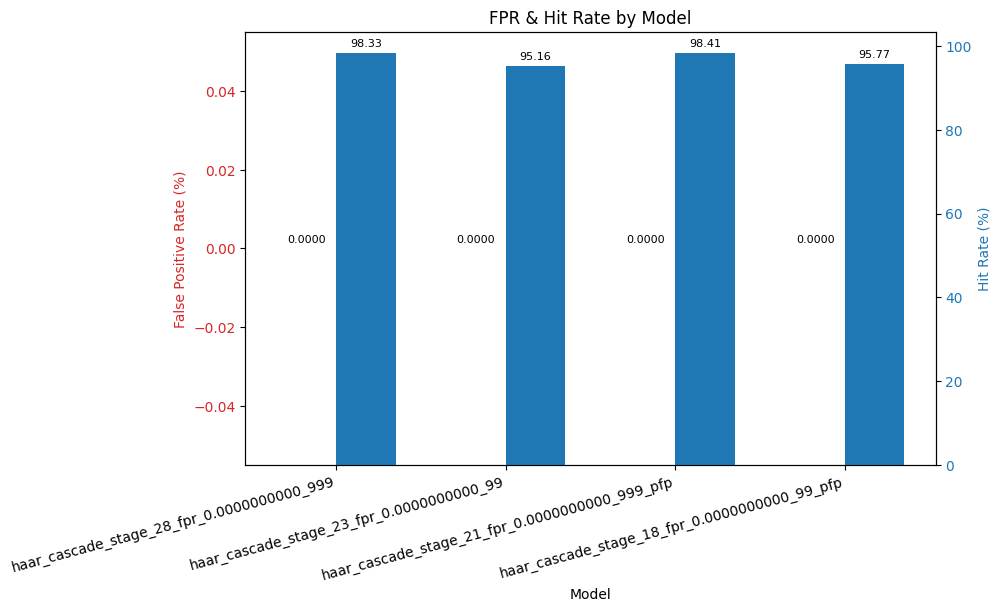

In [9]:
import matplotlib.pyplot as plt

names = [r["name"] for r in results]
fprs = [r["fpr"] * 100 for r in results]
tprs = [r["tpr"] * 100 for r in results]

x = np.arange(len(names))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, fprs, width, label='FPR (%)', color='tab:red')
bars2 = ax2.bar(x + width/2, tprs, width, label='Hit Rate (%)', color='tab:blue')

ax1.set_xlabel('Model')
ax1.set_ylabel('False Positive Rate (%)', color='tab:red')
ax2.set_ylabel('Hit Rate (%)', color='tab:blue')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=15, ha='right')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

fig.tight_layout()
plt.title('FPR & Hit Rate by Model')
plt.show()


# Missed Faces by Model (Interactive)


In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

N_SHOW = 20
N_ROWS = 4
N_COLS = 5

fig = make_subplots(
    rows=N_ROWS, cols=N_COLS,
    vertical_spacing=0.05, horizontal_spacing=0.05,
    subplot_titles=[f"Missed {i+1}" for i in range(N_SHOW)]
)

# For each model, prepare up to N_SHOW images
model_image_arrays = []
for r in results:
    imgs = []
    for path in r["missed_paths"][:N_SHOW]:
        img = cv2.imread(path)
        if img is None:
            img = np.full((100, 100, 3), 128, dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imgs.append(img)
    # pad with blanks if fewer than N_SHOW
    while len(imgs) < N_SHOW:
        imgs.append(np.full((100, 100, 3), 128, dtype=np.uint8))
    model_image_arrays.append(imgs)

# Add traces: for each subplot position, add one trace per model
trace_visibility_map = []  # list of lists: model_idx -> list of trace indices
for m in range(len(results)):
    trace_visibility_map.append([])

trace_idx = 0
for pos in range(N_SHOW):
    row = pos // N_COLS + 1
    col = pos % N_COLS + 1
    for m in range(len(results)):
        img = model_image_arrays[m][pos]
        trace = go.Image(z=img, visible=(m == 0))
        fig.add_trace(trace, row=row, col=col)
        trace_visibility_map[m].append(trace_idx)
        trace_idx += 1

# Build buttons
buttons = []
for m in range(len(results)):
    vis = [False] * trace_idx
    for ti in trace_visibility_map[m]:
        vis[ti] = True
    buttons.append(dict(
        label=results[m]["name"],
        method="update",
        args=[{"visible": vis},
              {"title": f"Missed Faces – {results[m]['name']} | Count: {len(results[m]['missed_paths'])}"}]
    ))

fig.update_layout(
    height=900, width=1100,
    title=f"Missed Faces – {results[0]['name']} | Count: {len(results[0]['missed_paths'])}",
    updatemenus=[dict(type="buttons", direction="down", showactive=True, buttons=buttons, x=1.05, xanchor="left", y=1.15, yanchor="top")]
)

fig.show()


# Single Image Predictions (Interactive)


In [ ]:
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots

filepaths = [
    '../data/ViolaJones/no_faces/open-images-v7/test/data/00a1039917ab1fb3.jpg',
    '../data/ViolaJones/G21391.jpg',
    '../data/ViolaJones/crowd1.png',
    '../data/ViolaJones/crowd2.png',
    '../data/ViolaJones/crowd3.png',
    '../data/ViolaJones/crowd4.png',
    '../data/ViolaJones/crowd5.png',
    '../data/ViolaJones/no_faces/all/0a0a3cef62f69def.jpg'
]

def draw_predictions_on_image(img_path, classifier, halve_size_factor=1):
    img = cv2.imread(img_path)
    if img is None:
        img = np.full((100, 100, 3), 128, dtype=np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    faces, _ = classifier.predict(
        img_path=img_path,
        return_candidate_count=True,
        halve_size=True,
        halve_size_factor=halve_size_factor
    )
    
    h_img, w_img = img.shape[:2]
    scale = max(1, int(halve_size_factor))
    boxed = img.copy()
    
    for face in faces:
        x = int(face['x'] * scale)
        y = int(face['y'] * scale)
        w = int(face['w'] * scale)
        h = int(face['h'] * scale)
        side = max(w, h)
        cx, cy = x + w // 2, y + h // 2
        x0 = max(0, cx - side // 2)
        y0 = max(0, cy - side // 2)
        x1 = min(w_img - 1, x0 + side)
        y1 = min(h_img - 1, y0 + side)
        cv2.rectangle(boxed, (x0, y0), (x1, y1), (0, 255, 0), 2)
    
    return cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)

# Precompute annotated images for all models and all filepaths
annotated_images = []
for m, r in enumerate(results):
    model_ann = []
    for fp in filepaths:
        ann = draw_predictions_on_image(fp, r["classifier"], halve_size_factor=1)
        model_ann.append(ann)
    annotated_images.append(model_ann)

fig = make_subplots(
    rows=1, cols=4,
    subplot_titles=[r["name"] for r in results],
    horizontal_spacing=0.05
)

# Add traces: for each model (column), add all filepath traces
trace_idx = 0
for m in range(len(results)):
    for i, fp in enumerate(filepaths):
        img = annotated_images[m][i]
        trace = go.Image(z=img, visible=(i == 0))
        fig.add_trace(trace, row=1, col=m+1)
        trace_idx += 1

# Build buttons to switch image
buttons = []
for i in range(len(filepaths)):
    vis = [False] * trace_idx
    for m in range(len(results)):
        vis[m * len(filepaths) + i] = True
    buttons.append(dict(
        label=os.path.basename(filepaths[i]),
        method="update",
        args=[{"visible": vis},
              {"title": f"Predictions – {filepaths[i]}"}]
    ))

fig.update_layout(
    height=500, width=1400,
    title=f"Predictions – {filepaths[0]}",
    updatemenus=[dict(type="buttons", direction="down", showactive=True, buttons=buttons, x=1.05, xanchor="left", y=1.15, yanchor="top")]
)

fig.show()


[ WARN:256@842.081] global loadsave.cpp:278 findDecoder imread_('../data/ViolaJones/no_faces/open-images-v7/test/data/00a1039917ab1fb3.jpg'): can't open/read file: check file path/integrity
[ WARN:256@843.253] global loadsave.cpp:278 findDecoder imread_('../data/ViolaJones/no_faces/open-images-v7/test/data/00a1039917ab1fb3.jpg'): can't open/read file: check file path/integrity
[ WARN:256@844.371] global loadsave.cpp:278 findDecoder imread_('../data/ViolaJones/no_faces/open-images-v7/test/data/00a1039917ab1fb3.jpg'): can't open/read file: check file path/integrity
[ WARN:256@845.515] global loadsave.cpp:278 findDecoder imread_('../data/ViolaJones/no_faces/open-images-v7/test/data/00a1039917ab1fb3.jpg'): can't open/read file: check file path/integrity
